In [1]:
import sys
sys.path.append('/data/taylor_group/Nima/ATLAS')
sys.path.append('../')

import json
import pickle
import copy 
import random 
import glob
from functools import partial
from tqdm.auto import trange
import tqdm_joblib
from joblib import Parallel, delayed

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax.scipy.linalg as jsl
import jax
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.distributions import constraints

from jug.engine.session import TimingSession

from ATLAS.data import PTA_Data
from ATLAS.psd_functions import *
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS import parameterized
from ATLAS.signals.timing.base import build_multi_psr_timing_model, MultiPsrTimingModel
from ATLAS.signals.timing.base import setup_timing_model
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils
from ATLAS import pulsar

# import MultiHMCGibbs

from ATLAS.samplers.canetoadracing import MultiHMCGibbs, MultiHMCGibbsWithAnalytic, AnalyticRhoTransition

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
hist_settings = dict(
    bins = 'auto',
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading data

## Option 1: To test the full capability of `ATLAS`, we only need par and tim files.

### We are using the `enterprise` pulsar object. This will be replaced by an in-house object very soon.

In [3]:
from enterprise.pulsar import Pulsar

In [4]:
pnames = ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 'J1713+0747', 
'J1719-1438', 'J1730-2304', 
'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 
'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 
'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 
'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 'J2229+2643', 'J2234+0611', 
'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']
len(pnames)

67

In [5]:
parfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/par/*.par'))
timfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/tim/*.tim'))

### Filter the par and tim files to remove "ao-only" files

In [7]:
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)

timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)

In [8]:
assert len(parfiles) == len(pnames)

In [9]:
Npulsars = len(pnames) # how many pulsars do you want?
Npulsars

67

In [10]:
# def doit(pidx):
#     return Pulsar(parfiles[pidx], timfiles[pidx], sort=True, ephem='DE440', timing_package='PINT')
# with tqdm_joblib.tqdm_joblib(desc="PINT Loading...", total=len(parfiles)) as progress_bar:
#     psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(len(parfiles)))

# with open('../data/NG15/NG15_v1p1_final_pint_psrs_sorted.pkl', 'wb') as fout:
#     pickle.dump(psrs, fout)

In [11]:
with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'rb') as fin:
    psrs = pickle.load(fin)
psrs = [psr for psr in psrs if psr.name != 'J1713+0747']

In [12]:
with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [13]:
chosen_pidx = 0 #np.argmin([len(psr.toas) for psr in psrs])
chosen_pidx 

0

In [14]:
psrs = psrs[chosen_pidx :chosen_pidx +1]

In [15]:
len(psrs)

1

In [16]:
psrs[0].name

'B1855+09'

In [17]:
timfiles[chosen_pidx :chosen_pidx +1]

['/data/taylor_group/Nima/tim/B1855+09_PINT_20220301.nb.tim']

## Option 2: If you do not want to vary the timing model params, use the pre-made 15 year pulsar objects.

In [3]:
from enterprise.pulsar import FeatherPulsar

In [4]:
# feather_files = glob.glob('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/*.feather')
feather_files = glob.glob('../data/NG15/feathers/*.feather')
psrs_all = []
for feather_file in feather_files:
    psr = FeatherPulsar.read_feather(feather_file)
    psrs_all.append(psr)

with open('../data/NG15/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0610-2100.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers

In [5]:
psrs = psrs_all[:3]

In [6]:
len(psrs)

3

# Model Construction

## White Noise Model

In [7]:
data = PTA_Data(psrs, 
                fixed_res = False,
                marg_timing=False, 
                diag_white_cov=False,
                linear_timing = True)
raw_res = jnp.concat(data.raw_residuals)

In [8]:
wn_model = WhiteCov(data = data)

  0%|          | 0/3 [00:00<?, ?it/s]

### Initial white noise guess

In [9]:
theta0_wn = wn_model.params_dict_to_vector(noise_dict)
theta0_wn[:5]

Array([ 1.04982172,  0.96948031, -6.17884779, -5.56093065, -7.03963453],      dtype=float64)

In [10]:
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds
wn_lower_bound, wn_upper_bound

(Array([ 0.01,  0.01, -9.  , -9.  , -9.  , -9.  ,  0.01,  0.01,  0.01,
         0.01, -9.  , -9.  , -9.  , -9.  , -9.  , -9.  , -9.  , -9.  ,
         0.01,  0.01, -9.  , -9.  , -9.  , -9.  ], dtype=float64),
 Array([10., 10., -5., -5., -5., -5., 10., 10., 10., 10., -5., -5., -5.,
        -5., -5., -5., -5., -5., 10., 10., -5., -5., -5., -5.],      dtype=float64))

## Red Noise Model

In [11]:
non_gwb_nfreqs = 30
gwb_nfreqs = 14

In [12]:
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)

# sig_dm = Red(name='dm',
#             psd_function = partial(powerlaw),
#             nfreqs=non_gwb_nfreqs,
#             lower_bound_psd = jnp.array([-18, 0.]),
#             upper_bound_psd = jnp.array([-11, 7.0]),
#             data = data,
#             use_pulsar_tspan = False)

sig_cor = Correlated(name='cor',
            psd_function = partial(powerlaw, gamma = 13/3),
            orf_function = hd_orf,
            nfreqs=gwb_nfreqs,
            lower_bound_psd = jnp.array([-18]),
            upper_bound_psd = jnp.array([-11]),
            data = data)

In [13]:
# build CW signal
from ATLAS.signals.deterministic.base import Deterministic
from ATLAS.signals.deterministic.det_signals import cw_delay_evolve_float64

cw_param_mins = np.array([7.2, -8.7, -1., 0, -18., -1., 0., 0.])
cw_param_maxs = np.array([9., -8.2, 1., np.pi, -12., 1., 2. * np.pi, 2. * np.pi])
cw_parameter_bounds = np.array([cw_param_mins, cw_param_maxs]).T

sig_cw = Deterministic(name='cw',
                         data=data,
                         get_delays_func=cw_delay_evolve_float64,
                         det_parameter_bounds=cw_parameter_bounds)

In [14]:
cfg = sutils.parse_basis_string("ltm|unc + cor -> unc ; cw")

In [15]:
cfg

{'include_timing': True,
 'shared_names': ['unc', 'cor'],
 'representative': 'unc',
 'separate_names': ['cw'],
 'order': ['unc', 'cor', 'cw']}

In [16]:
# sig = SuperSignal(signal_list = [sig_unc, sig_cor, sig_dm],
#                 signal_combination_string = "ltm|cor + unc -> unc; dm",
#                 data=data,
# )
sig = SuperSignal(signal_list = [sig_unc, sig_cor, sig_cw],
                signal_combination_string = "ltm|unc + cor -> unc ; cw",
                data=data,
)

In [17]:
x0 = sig.model.make_initial_guess(jrandom.key(12742)) #red noise model params
phi0 = sig.model.get_phi_mat_full(x0) #red noise cov matrix
phi0.shape, x0.shape

((30, 3, 3), (7,))

In [18]:
sig.signal_comb_idxs

{'timing': slice(0, 193, None),
 'unc': slice(193, 253, None),
 'cor': slice(193, 221, None),
 'cw': slice(253, 373, None)}

### `sig.get_helpers` updates the white noise covaraince matrix

In [19]:
TNT, TNr, rNr, logdetN = sig.get_helpers(reff = raw_res, 
                                        white_noise_params = theta0_wn, 
                                        #red_noise_basis = sig.get_Fmat_concat
                                        )
helpers = (TNT, TNr, rNr, logdetN)
TNT.shape, TNr.shape, rNr.shape, logdetN.shape

((3, 373, 373), (3, 373), (), ())

In [22]:
cor_idxs = sig.signal_comb_idxs['cor']
unc_tm_idxs = slice(sig.signal_comb_idxs['timing'].start, sig.signal_comb_idxs['unc'].stop)
det_idxs = sig.signal_comb_idxs['cw']
GG = TNT[:, cor_idxs, cor_idxs]
PP = TNT[:, unc_tm_idxs, unc_tm_idxs]
GP = TNT[:, cor_idxs, unc_tm_idxs]
DD = TNT[:, det_idxs, det_idxs]
GD = TNT[:, cor_idxs, det_idxs]
PD = TNT[:, unc_tm_idxs, det_idxs]
Gr = TNr[:, cor_idxs]
Pr = TNr[:, unc_tm_idxs]
Dr = TNr[:, det_idxs]

In [23]:
from jax import vmap

def partial_marg_lnposterior(helpers, red_params, D_params, z):
    
    # unpack and slice helper objects
    TNT, TNr, rNr, logdet_N = helpers
    GG = TNT[:, cor_idxs, cor_idxs]
    PP = TNT[:, unc_tm_idxs, unc_tm_idxs]
    GP = TNT[:, cor_idxs, unc_tm_idxs]
    DD = TNT[:, det_idxs, det_idxs]
    GD = TNT[:, cor_idxs, det_idxs]
    PD = TNT[:, unc_tm_idxs, det_idxs]
    Gr = TNr[:, cor_idxs, None]
    Pr = TNr[:, unc_tm_idxs, None]
    Dr = TNr[:, det_idxs, None]

    # get coefficients for deterministic signal
    det_params, psr_phases, psr_dists = D_params
    d = sig_cw.get_coeffs_func(det_params, psr_phases, psr_dists)[..., None]

    # get covariance matrices
    phiinv_G, logdet_phi_G, phiinv_P, logdet_phi_P = sig.model.partial_reparm_helper(red_params, sig._pad_mask)

    diag_idxs_P = jnp.arange(PP.shape[-1])
    Sigma_inv_P = PP.at[:, diag_idxs_P, diag_idxs_P].add(phiinv_P)
    Sigma_inv_P_chol_factors = vmap(lambda x: jsl.cho_factor(x, lower=True))(Sigma_inv_P)
    Sigma_P = vmap(lambda cf: jsl.cho_solve((cf[0], True),
                                            jnp.identity(cf[0].shape[0])))(Sigma_inv_P_chol_factors)
    logdet_Sigma_inv_P = 2 * jnp.sum(jnp.log(jnp.diagonal(Sigma_inv_P_chol_factors[0], axis1=1, axis2=2)))

    # build quadratic form of log-posterior
    U = jnp.sum(0.5 * Pr.mT @ Sigma_P @ Pr + 0.5 * d.mT @ PD.mT @ Sigma_P @ PD @ d \
                - Pr.mT @ Sigma_P @ PD @ d - 0.5 * rNr - 0.5 * d.mT @ DD @ d + d.mT @ Dr)
    V = -GP @ Sigma_P @ Pr + GP @ Sigma_P @ PD @ d + Gr - GD @ d
    W_inv_without_prior = -GP @ Sigma_P @ GP.mT + GG

    # normalization
    norm = -0.5 * (logdet_N + logdet_phi_G + logdet_phi_P + logdet_Sigma_inv_P)

    # standardizing transformation
    diag_idxs_G = jnp.arange(W_inv_without_prior.shape[-1])
    phiinv_G_diag = jnp.diagonal(phiinv_G, axis1=1, axis2=2).T
    W_inv_curn = W_inv_without_prior.at[:, diag_idxs_G, diag_idxs_G].add(phiinv_G_diag)
    W_inv_curn_L = jsl.cho_factor(W_inv_curn, lower = True)
    g_hat = jsl.cho_solve(W_inv_curn_L, V)
    Lz = jax.lax.linalg.triangular_solve(W_inv_curn_L[0], z[..., None],
                                         left_side=True, lower=True, transpose_a=True)
    g = g_hat + Lz  # [npsr, nmodes, 1]
    lndet_Jac = -jnp.sum(jnp.log(W_inv_curn_L[0].diagonal(axis1=-2, axis2=-1)))

    ln_likelihood = U + g.mT @ V - 0.5 * g.mT @ W_inv_without_prior @ g
    lnprior = -0.5 * (g.transpose(1, 2, 0) @ phiinv_G @ g.transpose(1, 0, 2)).sum()
    
    result = jnp.sum(norm + ln_likelihood + lnprior + lndet_Jac)
    return result, g


In [24]:
# test likelihood evaluation
cw_params0 = jrandom.uniform(key=jrandom.key(554),
                             shape=cw_param_maxs.shape,
                             minval=jnp.array(cw_param_mins),
                             maxval=jnp.array(cw_param_maxs))
psr_standard_dists0 = jrandom.normal(key=jrandom.key(559),
                                     shape=(data.npsrs,))
psr_dists_measured = jnp.array([psr.pdist[0] for psr in psrs])
psr_dists_std = jnp.array([psr.pdist[1] for psr in data.psrs])
psr_dists0 = psr_standard_dists0 * psr_dists_std + psr_dists_measured
psr_phases0 = jrandom.uniform(key=jrandom.key(991),
                              shape=(data.npsrs,),
                              minval=0.,
                              maxval=2.*jnp.pi)
z0 = jrandom.normal(key=jrandom.key(88008),
                    shape=(data.npsrs, 2 * gwb_nfreqs))

In [25]:
lnpost_val, _ = partial_marg_lnposterior(helpers=helpers,
                         red_params=x0,
                         D_params=(cw_params0, psr_phases0, psr_dists0),
                         z=z0)
print(lnpost_val)

790600.498897908


In [26]:
def partial_marg_sampling_model():

    # CW parameters
    cw_params = numpyro.sample('cw_params', dist.Uniform(sig_cw.det_param_mins, sig_cw.det_param_maxs))
    psr_phases = numpyro.sample('psr_phases', dist.Uniform(0., 2.*jnp.pi).expand((sig.npsrs,)))
    psr_dists_standard = numpyro.sample('psr_dists_standard', dist.Normal().expand((sig.npsrs,)))
    psr_dists = numpyro.deterministic('psr_dists', psr_dists_measured + psr_dists_std * psr_dists_standard)

    # whitened GWB coefficients
    z = numpyro.sample('z', dist.Normal().expand((sig.npsrs, 2 * gwb_nfreqs)))

    # red parameters
    red_params = numpyro.sample('red_params', dist.Uniform(sig.model.lower_prior_lim_all, sig.model.upper_prior_lim_all))

    # evaluate posterior
    lnpost_val, g = partial_marg_lnposterior(helpers=helpers,
                                             red_params=red_params,
                                             D_params=(cw_params, psr_phases, psr_dists),
                                             z=z)
    numpyro.factor('lnpost', lnpost_val)
    numpyro.deterministic('g', g)

In [27]:
nuts_kernel = NUTS(model=partial_marg_sampling_model)
mcmc = MCMC(sampler=nuts_kernel,
            num_warmup=500,
            num_samples=1000)
mcmc.run(jrandom.key(200129))
samples = mcmc.get_samples()

sample: 100%|██████████| 1500/1500 [06:22<00:00,  3.92it/s, 15 steps of size 1.90e-01. acc. prob=0.89]


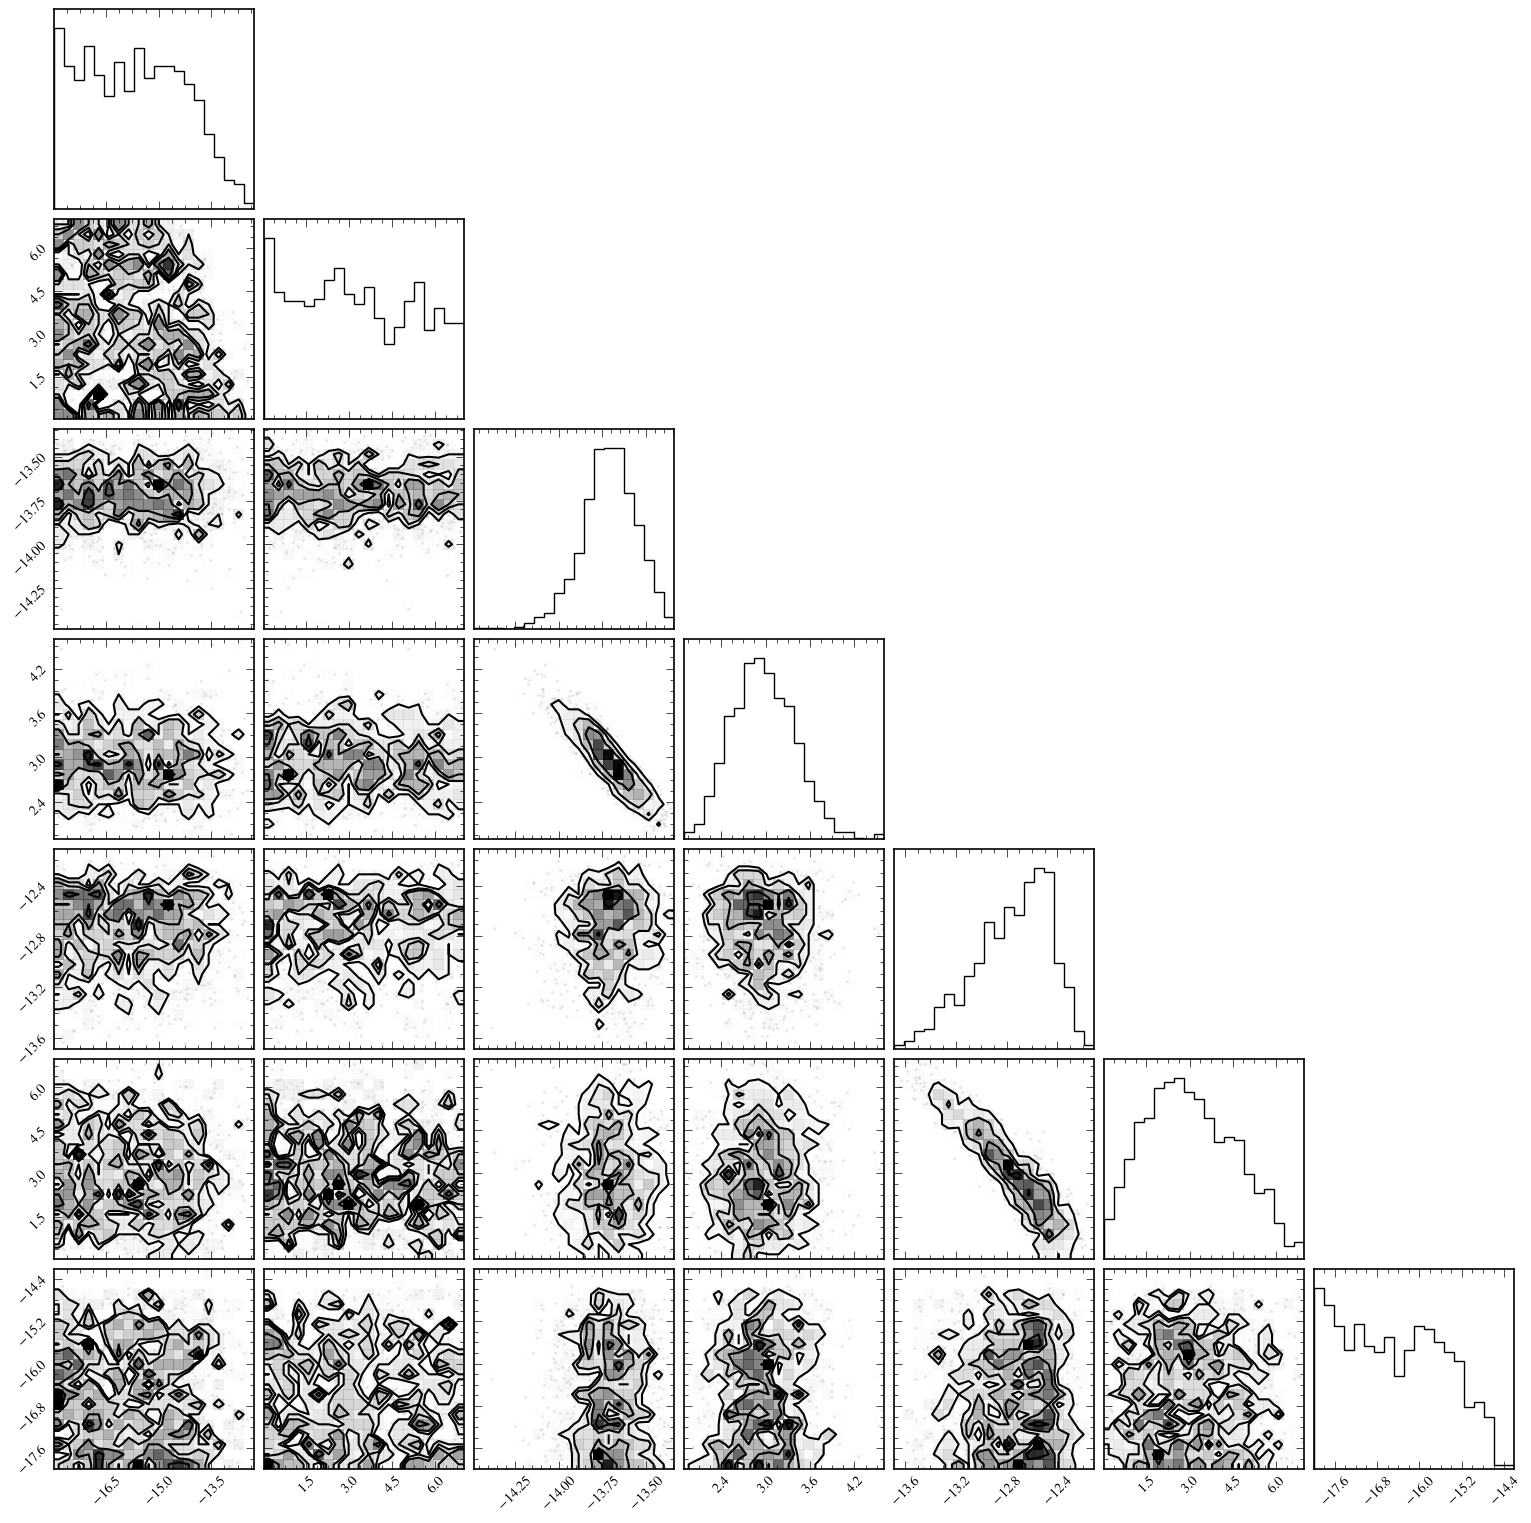

In [35]:
import corner

fig = corner.corner(data=np.array(samples['red_params']))

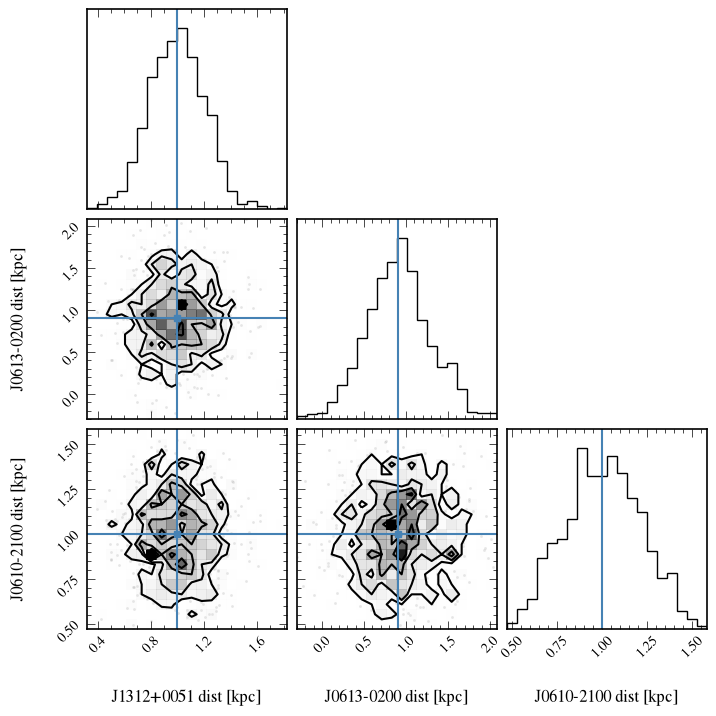

In [34]:
fig = corner.corner(data=np.array(samples['psr_dists']),
                    truths=psr_dists_measured,
                    labels=[f'{psr.name} dist [kpc]' for psr in data.psrs])